# Fertility Rate Analysis in OECD Countries

**Dependent variable:** `fertility_rate`
**Independent variables:** `inflation`, `unemployment_total`, `female_labor_force_participation`, `gdp_per_capita`, `marriage_rate`, `income_share_top10`, `wealth_share_top10`, `income_wealth_ratio`
**Categorical labels:** `region_tag`, `income_level`, `country_group`

**Scope:** 34 OECD countries, 2000–2024, 850 rows, 100% complete

### Data Sources

| Variable | Source | Indicator Code |
|---|---|---|
| `fertility_rate` | World Bank API v2 | `SP.DYN.TFRT.IN` |
| `inflation` | World Bank API v2 | `FP.CPI.TOTL.ZG` |
| `unemployment_total` | World Bank API v2 | `SL.UEM.TOTL.ZS` |
| `female_labor_force_participation` | World Bank API v2 | `SL.TLF.CACT.FE.ZS` |
| `gdp_per_capita` | World Bank API v2 (PPP, current int'l $) | `NY.GDP.PCAP.PP.CD` |
| `marriage_rate` | OECD Family Database SF3.1 | Crude marriage rate per 1,000 |
| `income_share_top10` | World Inequality Database (WID) | `sptinc_z` (p90p100) |
| `wealth_share_top10` | World Inequality Database (WID) | `shweal_z` (p90p100) |
| `income_wealth_ratio` | Derived from WID | `income_share_top10 / wealth_share_top10` |
| `income_level` | World Bank API v2 | `incomeLevel.value` |
| `region_tag` | Manual mapping based on geography | 9 regions |

All World Bank data fetched programmatically via `src/data_collection.py`. OECD marriage rate data downloaded from the [OECD Family Database](https://www.oecd.org/en/data/datasets/oecd-family-database.html) (SF3.1 Marriage and Divorce Rates). WID inequality data is parsed from `WID_Data_*.csv` and standardized as `data/raw/wid_inequality.csv`. Data cleaning and merging performed by `src/data_cleaning.py`.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import (shapiro, pearsonr, spearmanr,
                          f_oneway, kruskal, ttest_ind, mannwhitneyu, levene)
from scipy import stats as sp_stats
from itertools import combinations
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# --- Constants ---
NUMERIC_VARS = [
    "fertility_rate", "inflation", "unemployment_total",
    "female_labor_force_participation", "gdp_per_capita", "marriage_rate",
    "income_share_top10", "wealth_share_top10", "income_wealth_ratio",
]
INDEPENDENT_VARS = [
    "inflation", "unemployment_total", "female_labor_force_participation",
    "gdp_per_capita", "marriage_rate",
]
INEQUALITY_VARS = ["income_share_top10", "wealth_share_top10", "income_wealth_ratio"]
WITHIN_LAG_VARS = INDEPENDENT_VARS + INEQUALITY_VARS

VAR_LABELS = {
    "inflation": "Inflation (%)",
    "unemployment_total": "Unemployment (%)",
    "female_labor_force_participation": "Female Labor Force Participation (%)",
    "gdp_per_capita": "GDP per Capita (PPP, $)",
    "marriage_rate": "Marriage Rate (per 1,000)",
    "income_share_top10": "Top 10% Income Share",
    "wealth_share_top10": "Top 10% Wealth Share",
    "income_wealth_ratio": "Income/Wealth Ratio",
}
VAR_SHORT = {
    "inflation": "Inflation",
    "unemployment_total": "Unemployment",
    "female_labor_force_participation": "Female\nLFP",
    "gdp_per_capita": "GDP per\nCapita",
    "marriage_rate": "Marriage\nRate",
    "income_share_top10": "Top10\nIncome",
    "wealth_share_top10": "Top10\nWealth",
    "income_wealth_ratio": "Income/\nWealth Ratio",
}
GROUP_COLORS = {"developed": "#2196F3", "transition": "#FF9800", "special_case": "#F44336"}
GROUP_ORDER = ["developed", "transition", "special_case"]

# --- Load data ---
df = pd.read_csv("../data/processed/final_oecd.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"Country count: {df['country_code'].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape: (850, 17)
Columns: ['country', 'country_code', 'year', 'fertility_rate', 'inflation', 'unemployment_total', 'female_labor_force_participation', 'gdp_per_capita', 'marriage_rate', 'income_share_top10', 'wealth_share_top10', 'income_wealth_ratio', 'income_level', 'region_tag', 'country_group', 'marriage_rate_imputed', 'has_outlier']
Year range: 2000 - 2024
Country count: 34
Missing values: 0


## 1. Data Overview

In [32]:
print("=== DATA TYPES ===")
print(df.dtypes)
print()
print("=== FIRST 5 ROWS ===")
display(df.head())
print()
print("=== DESCRIPTIVE STATISTICS ===")
display(df[NUMERIC_VARS].describe().round(3))

=== DATA TYPES ===
country                                 str
country_code                            str
year                                  int64
fertility_rate                      float64
inflation                           float64
unemployment_total                  float64
female_labor_force_participation    float64
gdp_per_capita                      float64
marriage_rate                       float64
income_share_top10                  float64
wealth_share_top10                  float64
income_wealth_ratio                 float64
income_level                            str
region_tag                              str
country_group                           str
marriage_rate_imputed                   str
has_outlier                            bool
dtype: object

=== FIRST 5 ROWS ===


,country,country_code,year,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio,income_level,region_tag,country_group,marriage_rate_imputed,has_outlier
0,Australia,AUS,2000,1.756,4.457437,6.288,54.618,26584.819197,5.900,0.3189,0.5649,0.564525,High income,Oceania,developed,original,False
1,Australia,AUS,2001,1.739,4.407130,6.747,55.158,27687.758744,5.300,0.3171,0.5647,0.561537,High income,Oceania,developed,original,False
2,Australia,AUS,2002,1.756,2.981571,6.375,55.355,29080.043929,5.400,0.3264,0.5663,0.576373,High income,Oceania,developed,original,False
3,Australia,AUS,2003,1.748,2.732598,5.933,56.013,30167.241366,5.348,0.3261,0.5663,0.575843,High income,Oceania,developed,original,False
4,Australia,AUS,2004,1.768,2.343257,5.399,55.774,31814.504983,5.500,0.3329,0.5673,0.586815,High income,Oceania,developed,original,False



=== DESCRIPTIVE STATISTICS ===


,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio
count,850.000,850.000,850.000,850.000,850.000,850.000,850.000,850.000,850.000
mean,1.599,3.315,7.501,52.677,37653.129,4.737,0.374,0.598,0.622
std,0.298,5.415,4.029,7.352,18300.774,1.297,0.090,0.070,0.101
min,0.721,-4.448,2.015,23.114,6775.931,0.801,0.268,0.418,0.425
25%,1.370,1.229,4.614,49.676,25732.666,4.100,0.319,0.562,0.559
50%,1.560,2.354,6.634,53.481,35379.175,4.700,0.345,0.590,0.603
75%,1.796,3.605,9.252,57.697,46862.245,5.300,0.378,0.652,0.650
max,2.714,72.309,27.686,66.922,138522.518,9.500,0.683,0.743,0.932


In [33]:
stats_records = []
for col in NUMERIC_VARS:
    data = df[col].dropna()
    n = len(data)
    stats_records.append({
        "Variable": col, "N": n,
        "Mean": data.mean(), "Median": data.median(),
        "Std Dev (s)": data.std(ddof=1),
        "Variance (s\u00b2)": data.var(ddof=1),
        "Std Error": data.std(ddof=1) / np.sqrt(n),
        "Min": data.min(), "Q1": data.quantile(0.25),
        "Q3": data.quantile(0.75), "Max": data.max(),
        "Range": data.max() - data.min(),
        "IQR": data.quantile(0.75) - data.quantile(0.25),
        "Skewness": data.skew(), "Kurtosis": data.kurtosis(),
        "CV (%)": (data.std(ddof=1) / abs(data.mean())) * 100,
    })
stats_table = pd.DataFrame(stats_records).set_index("Variable")

print("=" * 70)
print("COMPREHENSIVE DESCRIPTIVE STATISTICS")
print("=" * 70)
display(stats_table.T.round(4))

print()
for group in GROUP_ORDER:
    subset = df[df["country_group"] == group]
    print(f"--- {group.upper()} (n={len(subset)}) ---")
    display(subset[NUMERIC_VARS].describe().round(4))

COMPREHENSIVE DESCRIPTIVE STATISTICS


Variable,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio
N,850.0000,850.0000,850.0000,850.0000,8.500000e+02,850.0000,850.0000,850.0000,850.0000
Mean,1.5991,3.3152,7.5011,52.6766,3.765313e+04,4.7368,0.3737,0.5979,0.6223
Median,1.5600,2.3544,6.6335,53.4810,3.537918e+04,4.7000,0.3449,0.5902,0.6033
Std Dev (s),0.2980,5.4148,4.0286,7.3518,1.830077e+04,1.2975,0.0897,0.0696,0.1011
Variance (s²),0.0888,29.3201,16.2296,54.0492,3.349183e+08,1.6835,0.0080,0.0048,0.0102
Std Error,0.0102,0.1857,0.1382,0.2522,6.277114e+02,0.0445,0.0031,0.0024,0.0035
Min,0.7210,-4.4475,2.0150,23.1140,6.775931e+03,0.8007,0.2678,0.4181,0.4248
Q1,1.3700,1.2290,4.6145,49.6760,2.573267e+04,4.1000,0.3189,0.5618,0.5591
Q3,1.7960,3.6047,9.2520,57.6970,4.686225e+04,5.3000,0.3778,0.6522,0.6499
Max,2.7140,72.3088,27.6860,66.9220,1.385225e+05,9.5000,0.6829,0.7433,0.9323



--- DEVELOPED (n=400) ---


,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio
count,400.0000,400.0000,400.0000,400.0000,400.0000,400.0000,400.0000,400.0000,400.0000
mean,1.6950,2.1586,6.0362,57.2115,48714.1984,4.7815,0.3409,0.5837,0.5872
std,0.2077,1.7382,2.1393,4.6493,17768.2734,0.9275,0.0368,0.0622,0.0584
min,1.2500,-4.4475,2.1190,41.7870,21500.1531,1.4000,0.2784,0.4533,0.4248
25%,1.5275,1.1222,4.4052,54.9820,36784.8418,4.3000,0.3170,0.5389,0.5556
50%,1.7100,1.9514,5.5535,57.9820,45177.3147,4.7000,0.3327,0.5766,0.5955
75%,1.8512,2.7227,7.4388,60.8565,57043.8203,5.2000,0.3601,0.6093,0.6286
max,2.1900,10.0012,15.4510,66.9220,138522.5178,8.2000,0.4686,0.7433,0.7147


--- TRANSITION (n=300) ---


,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio
count,300.0000,300.0000,300.0000,300.0000,300.0000,300.0000,300.0000,300.0000,300.0000
mean,1.6217,5.5457,8.5945,49.0349,24415.3199,4.7498,0.4234,0.6233,0.6699
std,0.3556,8.3462,4.0135,7.3860,11759.2382,1.7232,0.1273,0.0818,0.1330
min,1.1100,-1.1343,2.0150,23.1140,6775.9306,0.8007,0.2678,0.4181,0.4848
25%,1.3400,2.1311,5.7875,47.0700,15404.8235,3.6503,0.3190,0.5759,0.5585
50%,1.5500,3.5824,8.0655,51.1625,22275.2513,4.8000,0.3727,0.6212,0.6117
75%,1.7770,6.2761,10.8400,53.3452,30189.1571,5.6000,0.5578,0.6795,0.8199
max,2.7140,72.3088,20.5200,61.2580,57285.4237,9.5000,0.6829,0.7344,0.9323


--- SPECIAL_CASE (n=150) ---


,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio
count,150.0000,150.0000,150.0000,150.0000,150.0000,150.0000,150.0000,150.0000,150.0000
mean,1.2983,1.9383,9.2205,47.8671,34632.5642,4.5914,0.3617,0.5850,0.6207
std,0.1412,1.9165,6.0623,5.9513,9745.6892,1.1417,0.0407,0.0423,0.0762
min,0.7210,-1.7359,2.3510,35.3960,18819.8544,1.6000,0.2877,0.4725,0.4491
25%,1.2455,0.4726,3.9488,42.6123,27535.8393,3.7000,0.3316,0.5624,0.5689
50%,1.3300,2.0381,8.0170,49.4435,33045.5957,4.6000,0.3546,0.5896,0.6017
75%,1.3900,3.0863,11.6160,53.0285,40568.3672,5.3220,0.3807,0.5998,0.6679
max,1.5500,9.6453,27.6860,56.8260,62014.2675,7.0000,0.4479,0.6763,0.8024


## 2. Fertility Rate Trends

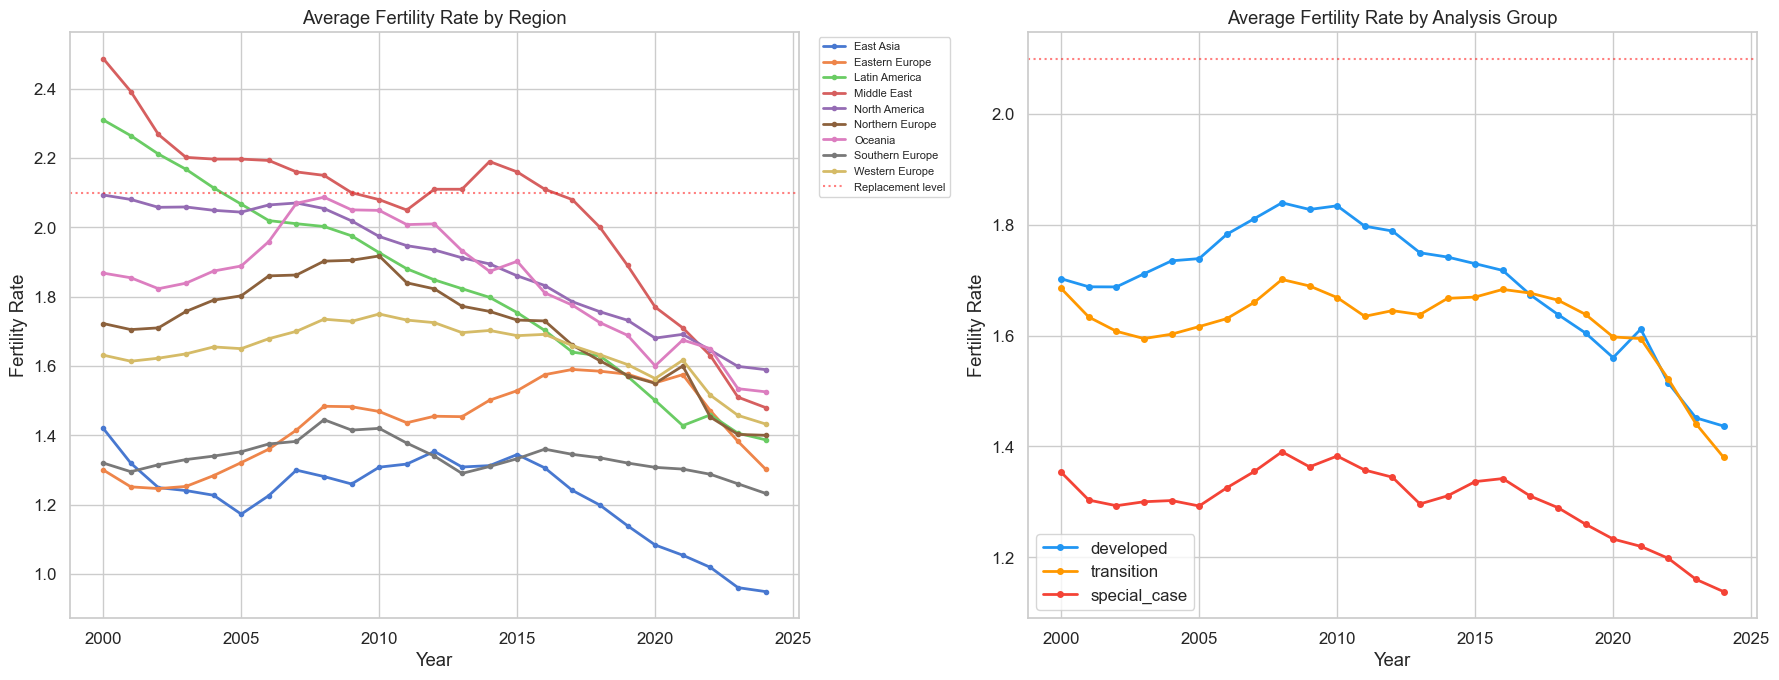

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: by region ---
region_trend = df.groupby(["region_tag", "year"])["fertility_rate"].mean().reset_index()
for region in sorted(df["region_tag"].unique()):
    s = region_trend[region_trend["region_tag"] == region]
    axes[0].plot(s["year"], s["fertility_rate"], marker="o", markersize=3, linewidth=2, label=region)
axes[0].set_title("Average Fertility Rate by Region")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Fertility Rate")
axes[0].axhline(y=2.1, color="red", linestyle=":", alpha=0.5, label="Replacement level")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

# --- Right: by analysis group ---
group_trend = df.groupby(["country_group", "year"])["fertility_rate"].mean().reset_index()
for group in GROUP_ORDER:
    s = group_trend[group_trend["country_group"] == group]
    axes[1].plot(s["year"], s["fertility_rate"], marker="o", markersize=4,
                 linewidth=2, color=GROUP_COLORS[group], label=group)
axes[1].set_title("Average Fertility Rate by Analysis Group")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Fertility Rate")
axes[1].axhline(y=2.1, color="red", linestyle=":", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/fertility_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Distributions & Group Comparisons

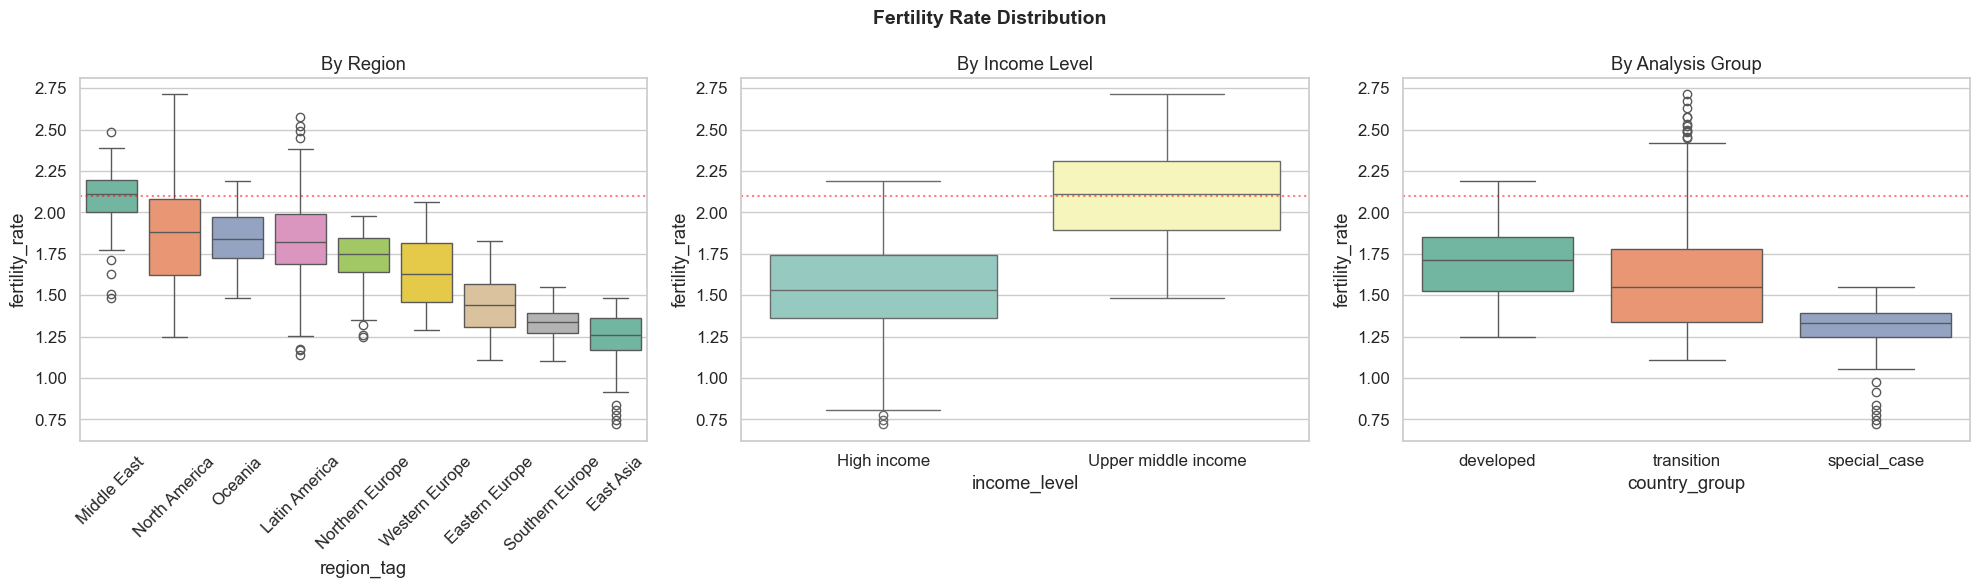

=== AVERAGES BY ANALYSIS GROUP ===


,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio
country_group,,,,,,,,,
developed,1.695,2.159,6.036,57.212,48714.198,4.781,0.341,0.584,0.587
special_case,1.298,1.938,9.220,47.867,34632.564,4.591,0.362,0.585,0.621
transition,1.622,5.546,8.594,49.035,24415.320,4.750,0.423,0.623,0.670



=== AVERAGES BY INCOME LEVEL ===


,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio
income_level,,,,,,,,,
High income,1.550,2.609,7.389,53.732,39611.883,4.743,0.354,0.588,0.602
Upper middle income,2.104,10.616,8.654,41.769,17412.671,4.675,0.581,0.695,0.835



=== AVERAGES BY REGION ===


,fertility_rate,inflation,unemployment_total,female_labor_force_participation,gdp_per_capita,marriage_rate,income_share_top10,wealth_share_top10,income_wealth_ratio
region_tag,,,,,,,,,
East Asia,1.224,1.455,3.582,50.980,37345.724,5.629,0.395,0.621,0.641
Eastern Europe,1.434,3.866,8.564,52.139,27550.791,4.942,0.339,0.584,0.583
Latin America,1.836,4.578,10.108,49.492,16482.332,2.336,0.616,0.722,0.854
Middle East,2.049,21.705,10.553,29.380,22090.597,7.860,0.531,0.649,0.817
North America,1.897,3.188,5.504,53.681,38813.004,5.409,0.472,0.674,0.695
Northern Europe,1.714,2.049,6.204,59.652,50511.024,5.023,0.318,0.559,0.577
Oceania,1.843,2.718,5.099,60.558,40216.213,4.847,0.349,0.572,0.609
Southern Europe,1.336,2.180,12.040,46.311,33275.984,4.073,0.345,0.567,0.611
Western Europe,1.645,2.013,6.113,54.695,49754.237,4.428,0.335,0.582,0.579


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Region boxplot
region_order = df.groupby("region_tag")["fertility_rate"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="region_tag", y="fertility_rate", order=region_order, ax=axes[0], palette="Set2")
axes[0].set_title("By Region")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(y=2.1, color="red", linestyle=":", alpha=0.5)

# Income level boxplot
sns.boxplot(data=df, x="income_level", y="fertility_rate", ax=axes[1], palette="Set3")
axes[1].set_title("By Income Level")
axes[1].axhline(y=2.1, color="red", linestyle=":", alpha=0.5)

# Analysis group boxplot
sns.boxplot(data=df, x="country_group", y="fertility_rate", order=GROUP_ORDER, ax=axes[2], palette="Set2")
axes[2].set_title("By Analysis Group")
axes[2].axhline(y=2.1, color="red", linestyle=":", alpha=0.5)

plt.suptitle("Fertility Rate Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/boxplots_all.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary tables
print("=== AVERAGES BY ANALYSIS GROUP ===")
display(df.groupby("country_group")[NUMERIC_VARS].mean().round(3))
print()
print("=== AVERAGES BY INCOME LEVEL ===")
display(df.groupby("income_level")[NUMERIC_VARS].mean().round(3))
print()
print("=== AVERAGES BY REGION ===")
display(df.groupby("region_tag")[NUMERIC_VARS].mean().round(3))

## 4. Pooled Correlation Analysis

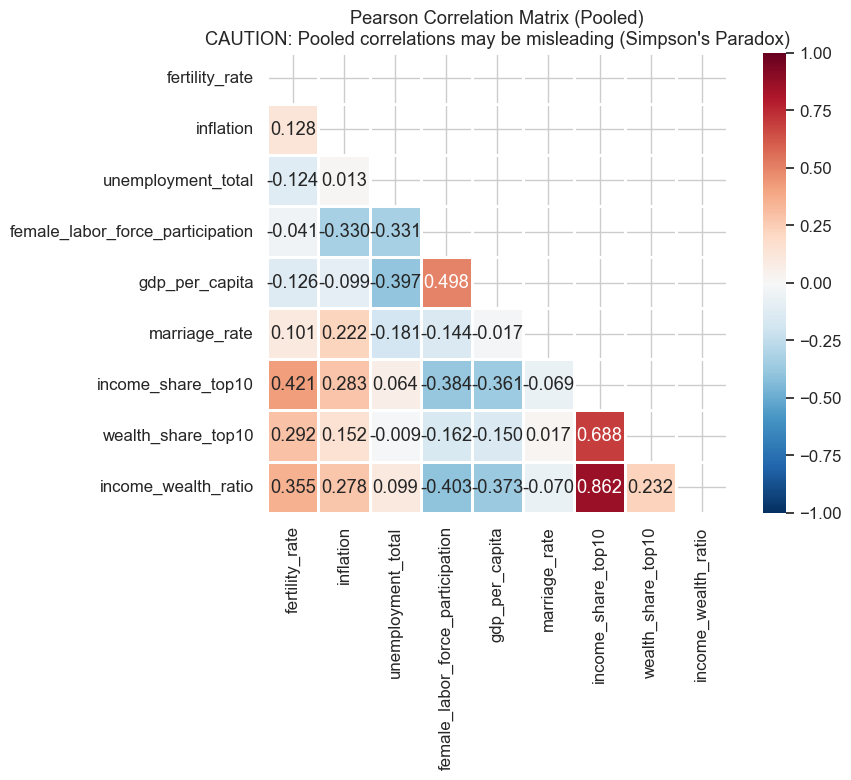


Pooled correlations with fertility_rate:
fertility_rate                      1.0000
income_share_top10                  0.4214
income_wealth_ratio                 0.3548
wealth_share_top10                  0.2919
inflation                           0.1285
marriage_rate                       0.1009
female_labor_force_participation   -0.0414
unemployment_total                 -0.1239
gdp_per_capita                     -0.1263
Name: fertility_rate, dtype: float64

⚠ These pooled values mix between-country and within-country variation.
  See Section 5 for the correct within-country analysis.


In [36]:
corr_matrix = df[NUMERIC_VARS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=1, ax=ax)
ax.set_title("Pearson Correlation Matrix (Pooled)\n"
             "CAUTION: Pooled correlations may be misleading (Simpson's Paradox)")
plt.tight_layout()
plt.savefig("../outputs/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPooled correlations with fertility_rate:")
print(corr_matrix["fertility_rate"].sort_values(ascending=False).round(4))
print("\n\u26a0 These pooled values mix between-country and within-country variation.")
print("  See Section 5 for the correct within-country analysis.")

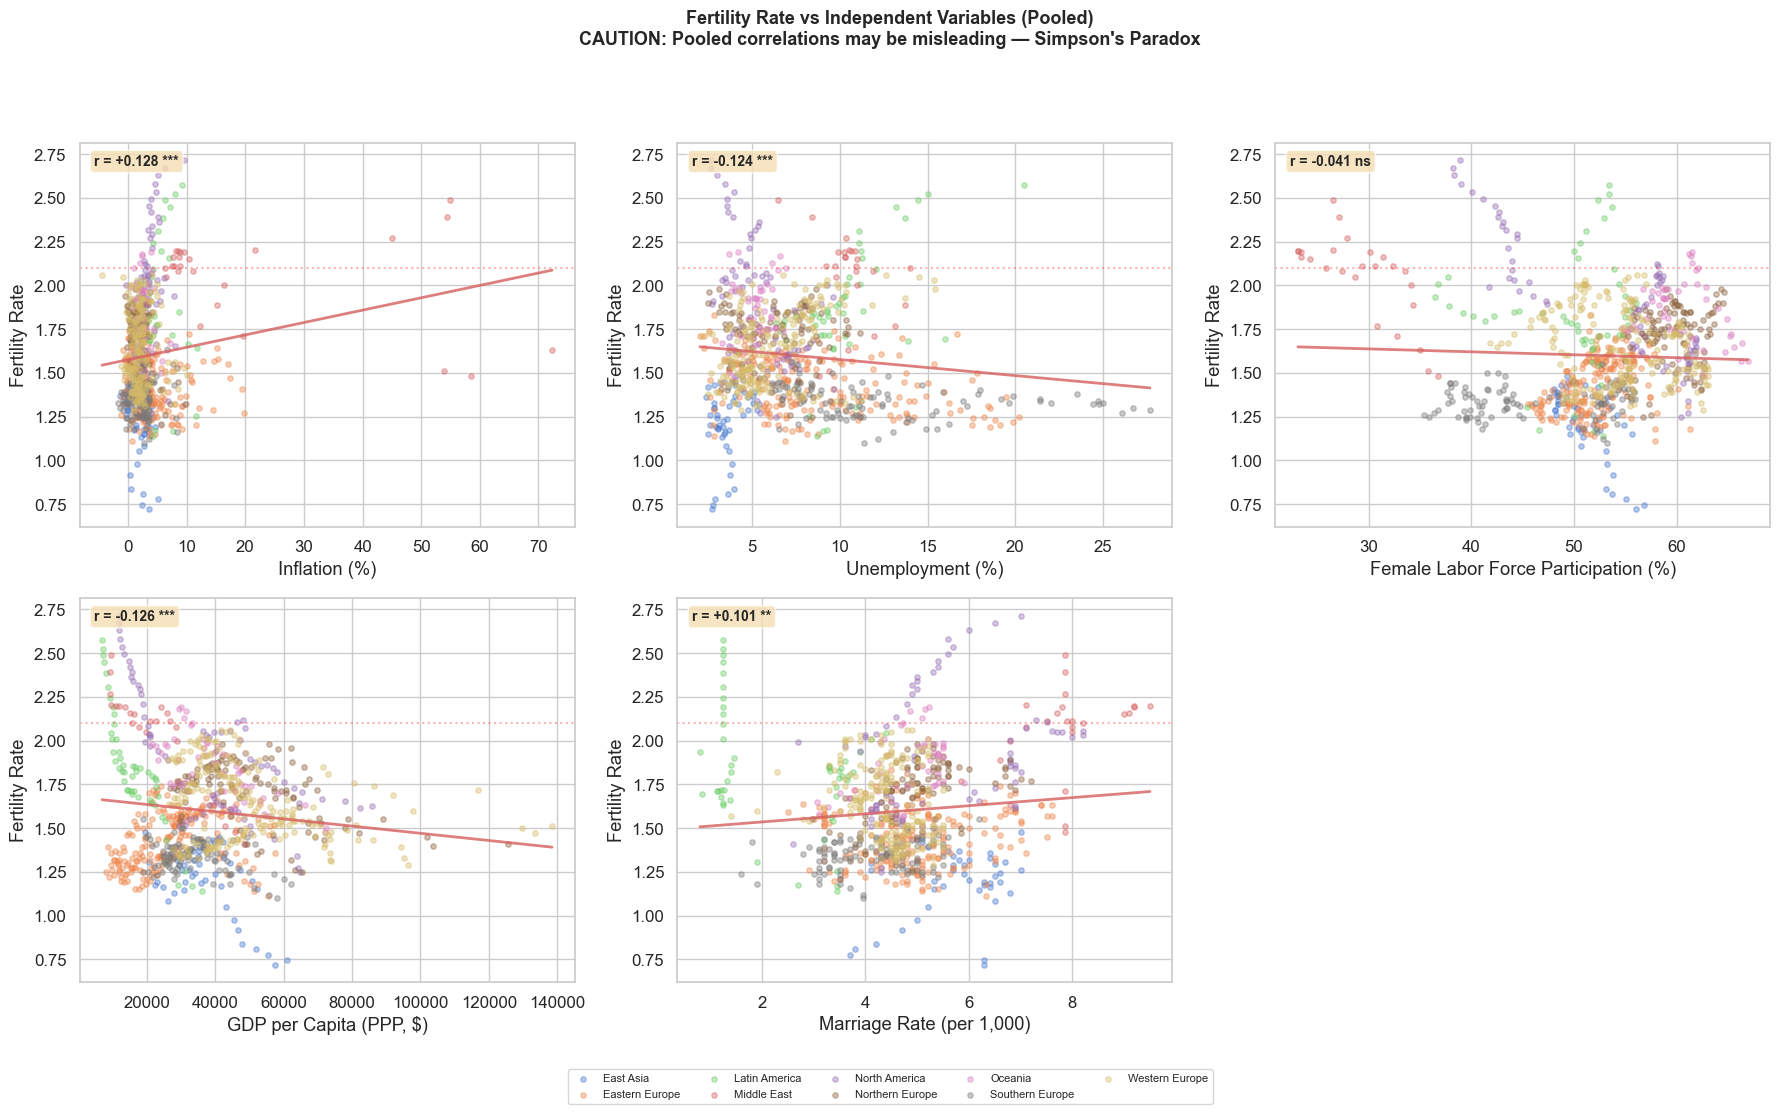

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for i, var in enumerate(INDEPENDENT_VARS):
    ax = axes_flat[i]
    for region in sorted(df["region_tag"].unique()):
        s = df[df["region_tag"] == region]
        ax.scatter(s[var], s["fertility_rate"], alpha=0.4, s=15, label=region)
    z = np.polyfit(df[var], df["fertility_rate"], 1)
    x_range = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x_range, np.poly1d(z)(x_range), "r-", linewidth=2, alpha=0.8)
    r, p = pearsonr(df[var], df["fertility_rate"])
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(0.03, 0.97, f"r = {r:+.3f} {star}", transform=ax.transAxes,
            fontsize=10, fontweight="bold", verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.set_xlabel(VAR_LABELS[var])
    ax.set_ylabel("Fertility Rate")
    ax.axhline(y=2.1, color="red", linestyle=":", alpha=0.3)

axes_flat[5].set_visible(False)
handles, labels_leg = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Fertility Rate vs Independent Variables (Pooled)\n"
             "CAUTION: Pooled correlations may be misleading \u2014 Simpson's Paradox",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig("../outputs/scatter_pooled_all.png", dpi=150, bbox_inches="tight")
plt.show()

### Simpson's Paradox: Inflation and GDP per Capita

The scatter plots above show a **positive** pooled correlation for inflation — suggesting "higher inflation = higher fertility." This is **misleading**:

- **Why?** Countries like Turkey, Mexico, and Colombia have both high inflation and high fertility. This is a **between-country** structural difference, not a causal relationship.
- **True relationship:** Within the same country, when inflation rises, fertility **declines** within 1 year (within-country ρ = −0.13).
- This phenomenon is known as **Simpson's Paradox**: the relationship within subgroups can be the opposite of the relationship in the aggregate data.

The figure below demonstrates this visually:

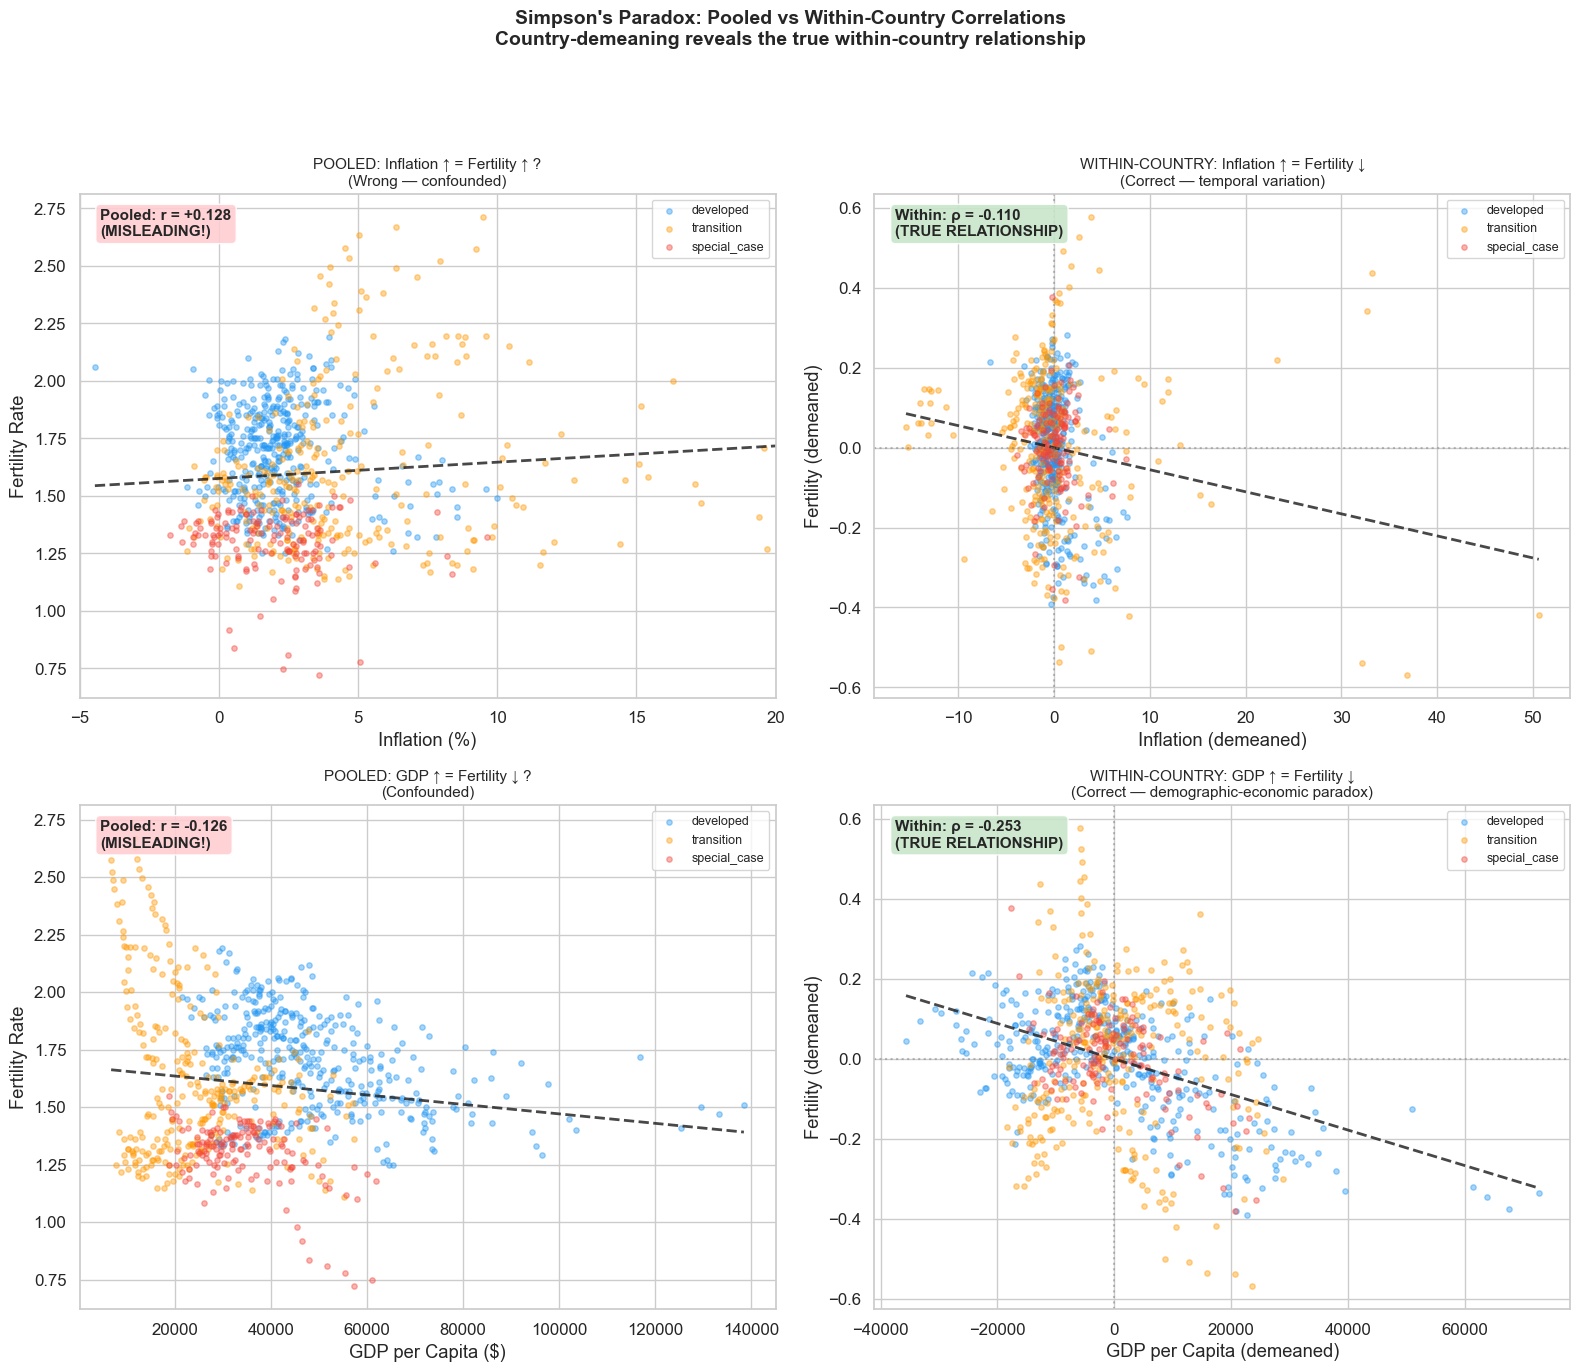

→ Inflation: Pooled r ≈ +0.13 (misleading) → Within ρ ≈ −0.11 (true: negative)
→ GDP: Pooled r ≈ −0.13 → Within ρ ≈ −0.25 (true: stronger negative)
→ Reason: High-inflation countries (Turkey/Mexico) also have structurally high fertility.


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Helper: country-demeaned columns
df_temp = df.copy()
for col in ["inflation", "gdp_per_capita", "fertility_rate"]:
    df_temp[col + "_dm"] = df_temp.groupby("country")[col].transform(lambda x: x - x.mean())

panels = [
    (0, 0, "inflation",    "fertility_rate", "Inflation (%)", "Fertility Rate",
     "POOLED: Inflation \u2191 = Fertility \u2191 ?\n(Wrong \u2014 confounded)", False),
    (0, 1, "inflation_dm", "fertility_rate_dm", "Inflation (demeaned)", "Fertility (demeaned)",
     "WITHIN-COUNTRY: Inflation \u2191 = Fertility \u2193\n(Correct \u2014 temporal variation)", True),
    (1, 0, "gdp_per_capita",    "fertility_rate", "GDP per Capita ($)", "Fertility Rate",
     "POOLED: GDP \u2191 = Fertility \u2193 ?\n(Confounded)", False),
    (1, 1, "gdp_per_capita_dm", "fertility_rate_dm", "GDP per Capita (demeaned)", "Fertility (demeaned)",
     "WITHIN-COUNTRY: GDP \u2191 = Fertility \u2193\n(Correct \u2014 demographic-economic paradox)", True),
]

for row, col_idx, x_col, y_col, xlabel, ylabel, title, is_within in panels:
    ax = axes[row, col_idx]
    for group in GROUP_ORDER:
        s = df_temp[df_temp["country_group"] == group]
        ax.scatter(s[x_col], s[y_col], alpha=0.4, s=15, color=GROUP_COLORS[group], label=group)

    z = np.polyfit(df_temp[x_col], df_temp[y_col], 1)
    x_range = np.linspace(df_temp[x_col].min(), df_temp[x_col].max(), 100)
    ax.plot(x_range, np.poly1d(z)(x_range), "k--", linewidth=2, alpha=0.8)

    if is_within:
        rho, p = spearmanr(df_temp[x_col], df_temp[y_col])
        label = f"Within: \u03c1 = {rho:+.3f}\n(TRUE RELATIONSHIP)"
        color = "#C8E6C9"
        ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
        ax.axvline(0, color="gray", linestyle=":", alpha=0.5)
    else:
        rho, p = pearsonr(df_temp[x_col], df_temp[y_col])
        label = f"Pooled: r = {rho:+.3f}\n(MISLEADING!)"
        color = "#FFCDD2"

    ax.text(0.03, 0.97, label, transform=ax.transAxes, fontsize=11, fontweight="bold",
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor=color, alpha=0.9))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

if "inflation" in df_temp.columns:
    axes[0, 0].set_xlim(-5, 20)

plt.suptitle("Simpson's Paradox: Pooled vs Within-Country Correlations\n"
             "Country-demeaning reveals the true within-country relationship",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../outputs/simpsons_paradox.png", dpi=150, bbox_inches="tight")
plt.show()

print("\u2192 Inflation: Pooled r \u2248 +0.13 (misleading) \u2192 Within \u03c1 \u2248 \u22120.11 (true: negative)")
print("\u2192 GDP: Pooled r \u2248 \u22120.13 \u2192 Within \u03c1 \u2248 \u22120.25 (true: stronger negative)")
print("\u2192 Reason: High-inflation countries (Turkey/Mexico) also have structurally high fertility.")

## 5. Within-Country (Country-Demeaned) Analysis

Our hypothesis is explicitly **within-country temporal**: "when a country's economy worsens, does its fertility rate decline?"

To isolate within-country dynamics we:
1. **Country-demean** each variable (subtract each country's mean) → removes structural between-country differences
2. **Test lagged correlations** (0–5 years) → economic shocks don't affect fertility instantly

In [39]:
# --- Country-demeaning ---
df_sorted = df.sort_values(["country", "year"]).copy()
demean_cols = ["fertility_rate"] + WITHIN_LAG_VARS
for col in demean_cols:
    df_sorted[col + "_dm"] = df_sorted.groupby("country")[col].transform(lambda x: x - x.mean())

# --- Within-country (lag=0) Spearman correlations ---
print("=" * 95)
print("WITHIN-COUNTRY (COUNTRY-DEMEANED) SPEARMAN CORRELATIONS")
print("  Each country's mean subtracted → only temporal variation remains")
print("=" * 95)
print(f"{'Variable':<40} {'Pooled ρ':>10} {'Within ρ':>10} {'':>5} {'Direction Change?':>18}")
print("-" * 95)

within_results = {}
for var in WITHIN_LAG_VARS:
    c_pool = df_sorted[["fertility_rate", var]].dropna()
    rho_pool, _ = spearmanr(c_pool["fertility_rate"], c_pool[var])
    c_within = df_sorted[["fertility_rate_dm", var + "_dm"]].dropna()
    rho_within, p_within = spearmanr(c_within["fertility_rate_dm"], c_within[var + "_dm"])
    within_results[var] = {"rho": rho_within, "p": p_within}
    changed = "YES ⚠" if (rho_pool > 0) != (rho_within > 0) else "no"
    star = "***" if p_within < 0.001 else "**" if p_within < 0.01 else "*" if p_within < 0.05 else "ns"
    print(f"{var:<40} {rho_pool:>+10.4f} {rho_within:>+10.4f} {star:>5}  {changed:>10}")

print("\n→ Pooled vs Within differences reveal Simpson's paradox / confounding.")

# --- Lagged correlations ---
max_lag = 5
print("\n" + "=" * 100)
print("LAGGED WITHIN-COUNTRY CORRELATIONS (Spearman)")
print("  fertility_rate(t) vs variable(t - lag)")
print("=" * 100)

lag_results = {}
header = f"{'Variable':<40}"
for lag in range(max_lag + 1):
    header += f" {'lag=' + str(lag):>8}"
print(header)
print("-" * 100)

for var in WITHIN_LAG_VARS:
    row = f"{var:<40}"
    lag_results[var] = {}
    for lag in range(max_lag + 1):
        if lag == 0:
            c = df_sorted[["fertility_rate_dm", var + "_dm"]].dropna()
            rho, p = spearmanr(c["fertility_rate_dm"], c[var + "_dm"])
        else:
            df_sorted["_lag"] = df_sorted.groupby("country")[var + "_dm"].shift(lag)
            c = df_sorted[["fertility_rate_dm", "_lag"]].dropna()
            rho, p = spearmanr(c["fertility_rate_dm"], c["_lag"])
        lag_results[var][lag] = {"rho": rho, "p": p, "n": len(c)}
        star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        row += f" {rho:>+7.3f}{star:1}"
    print(row)

if "_lag" in df_sorted.columns:
    df_sorted.drop(columns=["_lag"], inplace=True)

print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")
print()
print("=" * 75)
print("OPTIMAL LAG (strongest significant correlation)")
print("=" * 75)
for var in WITHIN_LAG_VARS:
    best_lag, best_rho = None, 0
    for lag in range(max_lag + 1):
        res = lag_results[var][lag]
        if res["p"] < 0.05 and abs(res["rho"]) > abs(best_rho):
            best_rho = res["rho"]
            best_lag = lag
    if best_lag is not None:
        r = lag_results[var][best_lag]
        print(f"  {var:<40} → lag={best_lag}, ρ={r['rho']:+.4f}, p={r['p']:.4f}, n={r['n']}")
    else:
        print(f"  {var:<40} → NO significant lag found")

WITHIN-COUNTRY (COUNTRY-DEMEANED) SPEARMAN CORRELATIONS
  Each country's mean subtracted → only temporal variation remains
Variable                                   Pooled ρ   Within ρ        Direction Change?
-----------------------------------------------------------------------------------------------
inflation                                   +0.0621    -0.1102    **       YES ⚠
unemployment_total                          -0.1020    -0.0262    ns          no
female_labor_force_participation            +0.2109    -0.0879     *       YES ⚠
gdp_per_capita                              +0.0050    -0.2529   ***       YES ⚠
marriage_rate                               +0.0869    +0.4220   ***          no
income_share_top10                          +0.1805    -0.0529    ns       YES ⚠
wealth_share_top10                          +0.1700    +0.0709     *          no
income_wealth_ratio                         +0.2064    -0.0833     *       YES ⚠

→ Pooled vs Within differences reveal Simpso

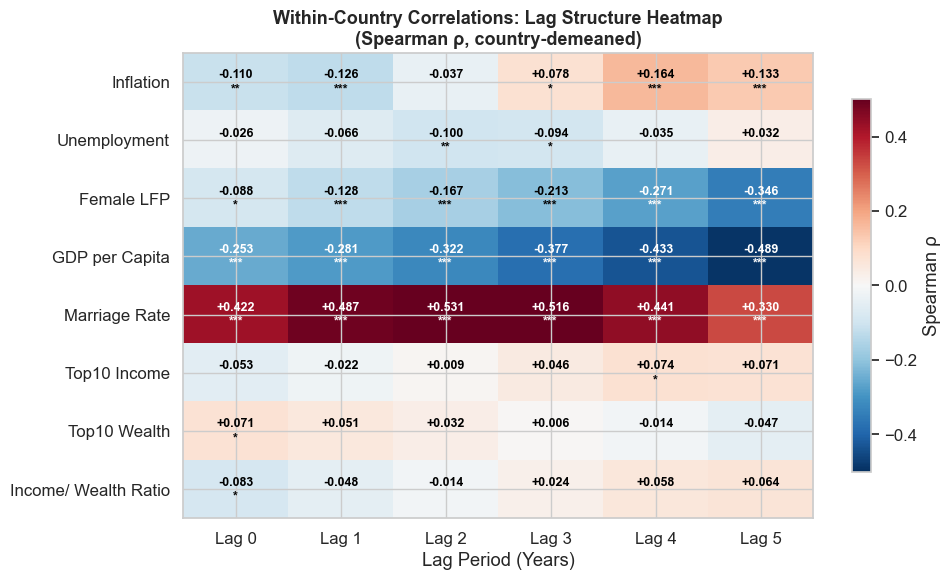

In [40]:
lag_matrix = np.zeros((len(WITHIN_LAG_VARS), max_lag + 1))
p_matrix   = np.zeros((len(WITHIN_LAG_VARS), max_lag + 1))
for i, var in enumerate(WITHIN_LAG_VARS):
    for j in range(max_lag + 1):
        lag_matrix[i, j] = lag_results[var][j]["rho"]
        p_matrix[i, j]   = lag_results[var][j]["p"]

fig_h = max(6, 0.75 * len(WITHIN_LAG_VARS))
fig, ax = plt.subplots(figsize=(10, fig_h))
im = ax.imshow(lag_matrix, cmap="RdBu_r", aspect="auto", vmin=-0.5, vmax=0.5)

for i in range(len(WITHIN_LAG_VARS)):
    for j in range(max_lag + 1):
        rho_val, p_val = lag_matrix[i, j], p_matrix[i, j]
        star = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        color = "white" if abs(rho_val) > 0.25 else "black"
        ax.text(j, i, f"{rho_val:+.3f}\n{star}", ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)

ax.set_xticks(range(max_lag + 1))
ax.set_xticklabels([f"Lag {l}" for l in range(max_lag + 1)])
ax.set_yticks(range(len(WITHIN_LAG_VARS)))
ax.set_yticklabels([VAR_SHORT[v].replace("\n", " ") for v in WITHIN_LAG_VARS])
ax.set_xlabel("Lag Period (Years)")
ax.set_title("Within-Country Correlations: Lag Structure Heatmap\n"
             "(Spearman ρ, country-demeaned)", fontsize=13, fontweight="bold")
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Spearman ρ")
plt.tight_layout()
plt.savefig("../outputs/lag_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Hypothesis Testing

### Research Question
**When a country's macroeconomic conditions and inequality structure deteriorate over time, does its fertility rate decline?**

### Sub-Hypotheses (α = 0.05)

| # | Variable | H₀ | H₁ | Tail | Rationale |
|---|---|---|---|---|---|
| **H1** | `unemployment_total` | ρ = 0 | ρ < 0 | one | Cyclical shock: job loss → economic insecurity → postpone children (lag: 2 yr) |
| **H2** | `female_labor_force_participation` | ρ = 0 | ρ < 0 | one | Structural trend: women in workforce → higher opportunity cost → fewer children |
| **H3** | `inflation` | ρ = 0 | ρ < 0 | one | Inflation erodes purchasing power (lag: 1 yr) |
| **H4** | `gdp_per_capita` | ρ = 0 | ρ ≠ 0 | **two** | Demographic-economic paradox |
| **H5** | `marriage_rate` | ρ = 0 | ρ > 0 | one | Marriage = primary pathway to parenthood |
| **H6** | `country_group` | μ₁=μ₂=μ₃ | At least one differs | — | Structural group differences |
| **H7** | `income_level` | μ_high = μ_upper | μ_high ≠ μ_upper | — | Income classification |
| **H8** | `income_share_top10` | ρ = 0 | ρ < 0 | one | Higher income concentration may suppress fertility |
| **H9** | `wealth_share_top10` | ρ = 0 | ρ < 0 | one | Higher wealth concentration may suppress fertility |

In [41]:
# --- Normality tests ---
print("=" * 65)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("=" * 65)
print(f"{'Variable':<40} {'W-stat':>8} {'p-value':>12} {'Normal?':>8}")
print("-" * 65)
for col in NUMERIC_VARS:
    w, p = shapiro(df[col].dropna())
    print(f"{col:<40} {w:>8.4f} {p:>12.2e} {'Yes' if p > 0.05 else 'No':>8}")
print("\n→ Most variables are non-normal → Spearman (rank) is the primary test.\n")

# --- Pooled correlation tests ---
print("=" * 75)
print("SPEARMAN CORRELATION with fertility_rate (pooled, two-tailed)")
print("=" * 75)
print(f"{'Variable':<40} {'ρs':>8} {'p-value':>12} {'Sig?':>10}")
print("-" * 75)
for var in WITHIN_LAG_VARS:
    rho, p = spearmanr(df["fertility_rate"], df[var])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{var:<40} {rho:>8.4f} {p:>12.6f} {sig:>10}")

# --- Directional hypothesis tests H1-H5 + H8-H9 ---
print("\n" + "=" * 90)
print("DIRECTIONAL HYPOTHESIS TESTS — WITHIN-COUNTRY (α = 0.05)")
print("=" * 90)

hypotheses = [
    {"name": "H1", "var": "unemployment_total",
     "direction": "negative", "tail": "one", "lag": 2,
     "H0": "ρ ≥ 0", "H1": "ρ < 0 (unemployment ↑ → fertility ↓, 2-yr lag)"},
    {"name": "H2", "var": "female_labor_force_participation",
     "direction": "negative", "tail": "one", "lag": 0,
     "H0": "ρ ≥ 0", "H1": "ρ < 0 (higher female LFP → lower fertility)"},
    {"name": "H3", "var": "inflation",
     "direction": "negative", "tail": "one", "lag": 1,
     "H0": "ρ ≥ 0", "H1": "ρ < 0 (inflation ↑ → fertility ↓, 1-yr lag)"},
    {"name": "H4", "var": "gdp_per_capita",
     "direction": "two-sided", "tail": "two", "lag": 0,
     "H0": "ρ = 0", "H1": "ρ ≠ 0 (GDP associated with fertility)"},
    {"name": "H5", "var": "marriage_rate",
     "direction": "positive", "tail": "one", "lag": 0,
     "H0": "ρ ≤ 0", "H1": "ρ > 0 (marriage ↑ → fertility ↑)"},
    {"name": "H8", "var": "income_share_top10",
     "direction": "negative", "tail": "one", "lag": 0,
     "H0": "ρ ≥ 0", "H1": "ρ < 0 (top income share ↑ → fertility ↓)"},
    {"name": "H9", "var": "wealth_share_top10",
     "direction": "negative", "tail": "one", "lag": 0,
     "H0": "ρ ≥ 0", "H1": "ρ < 0 (top wealth share ↑ → fertility ↓)"},
]

hyp_results = []
for h in hypotheses:
    var, lag = h["var"], h["lag"]
    if lag == 0:
        test_df = df_sorted[["fertility_rate_dm", var + "_dm"]].dropna()
        x_col = var + "_dm"
    else:
        df_sorted["_test_lag"] = df_sorted.groupby("country")[var + "_dm"].shift(lag)
        test_df = df_sorted[["fertility_rate_dm", "_test_lag"]].dropna()
        x_col = "_test_lag"

    rho, p_two = spearmanr(test_df["fertility_rate_dm"], test_df[x_col])
    r, p_two_r = pearsonr(test_df["fertility_rate_dm"], test_df[x_col])

    if h["tail"] == "one":
        if h["direction"] == "negative":
            p_s = p_two / 2 if rho < 0 else 1 - p_two / 2
            p_r = p_two_r / 2 if r < 0 else 1 - p_two_r / 2
        else:
            p_s = p_two / 2 if rho > 0 else 1 - p_two / 2
            p_r = p_two_r / 2 if r > 0 else 1 - p_two_r / 2
    else:
        p_s, p_r = p_two, p_two_r

    tail_label = "one-tailed" if h["tail"] == "one" else "two-tailed"
    print(f"\n--- {h['name']}: {var} (lag={lag}, {tail_label}) ---")
    print(f"  H₀: {h['H0']}   H₁: {h['H1']}")
    print(f"  n = {len(test_df)}")
    print(f"  Spearman: ρ = {rho:+.4f}, p = {p_s:.6f}  →  {'REJECT H₀ ✓' if p_s < 0.05 else 'FAIL TO REJECT ✗'}")
    print(f"  Pearson:  r = {r:+.4f}, p = {p_r:.6f}  →  {'REJECT H₀ ✓' if p_r < 0.05 else 'FAIL TO REJECT ✗'}")

    hyp_results.append({
        "Hypothesis": h["name"], "Variable": var, "Lag": lag, "Tail": tail_label,
        "Spearman ρ": round(rho, 4), "Spearman p": round(p_s, 6),
        "Decision": "Reject H₀" if p_s < 0.05 else "Fail to Reject",
    })

if "_test_lag" in df_sorted.columns:
    df_sorted.drop(columns=["_test_lag"], inplace=True)

NORMALITY TESTS (Shapiro-Wilk)
Variable                                   W-stat      p-value  Normal?
-----------------------------------------------------------------
fertility_rate                             0.9699     3.12e-12       No
inflation                                  0.4441     3.86e-45       No
unemployment_total                         0.8679     3.66e-26       No
female_labor_force_participation           0.9323     3.62e-19       No
gdp_per_capita                             0.9326     3.99e-19       No
marriage_rate                              0.9630     7.75e-14       No
income_share_top10                         0.7588     1.87e-33       No
wealth_share_top10                         0.9722     1.16e-11       No
income_wealth_ratio                        0.9069     2.33e-22       No

→ Most variables are non-normal → Spearman (rank) is the primary test.

SPEARMAN CORRELATION with fertility_rate (pooled, two-tailed)
Variable                                       ρ

In [42]:
# --- H6: Country group differences ---
print("=" * 70)
print("H6: COUNTRY GROUP DIFFERENCES IN FERTILITY RATE")
print("=" * 70)

groups = {name: group["fertility_rate"].values for name, group in df.groupby("country_group")}
for name, vals in groups.items():
    print(f"  {name:<15}: n={len(vals):>3}, mean={np.mean(vals):.4f}, std={np.std(vals, ddof=1):.4f}")

lev_stat, lev_p = levene(*groups.values())
print(f"\nLevene's test: F = {lev_stat:.4f}, p = {lev_p:.6f}")
h_stat, kw_p = kruskal(*groups.values())
print(f"Kruskal-Wallis: H = {h_stat:.4f}, p = {kw_p:.2e}")
print(f"  \u2192 {'REJECT H\u2080 \u2713' if kw_p < 0.05 else 'FAIL TO REJECT \u2717'}")

# --- H7: Income level differences ---
print("\n" + "=" * 70)
print("H7: INCOME LEVEL DIFFERENCE IN FERTILITY RATE")
print("=" * 70)
high = df[df["income_level"] == "High income"]["fertility_rate"].values
upper_mid = df[df["income_level"] == "Upper middle income"]["fertility_rate"].values
print(f"  High income:         n={len(high):>3}, mean={np.mean(high):.4f}")
print(f"  Upper middle income: n={len(upper_mid):>3}, mean={np.mean(upper_mid):.4f}")

equal_var = levene(high, upper_mid)[1] > 0.05
u_stat, mw_p = mannwhitneyu(high, upper_mid, alternative="two-sided")
print(f"Mann-Whitney U: U = {u_stat:.1f}, p = {mw_p:.2e}")
print(f"  \u2192 {'REJECT H\u2080 \u2713' if mw_p < 0.05 else 'FAIL TO REJECT \u2717'}")

# --- Post-hoc pairwise ---
print("\n" + "=" * 70)
print("POST-HOC PAIRWISE (Bonferroni-adjusted \u03b1 = 0.0167)")
print("=" * 70)
group_names = list(groups.keys())
bonferroni_alpha = 0.05 / len(list(combinations(group_names, 2)))
for g1, g2 in combinations(group_names, 2):
    u, p = mannwhitneyu(groups[g1], groups[g2], alternative="two-sided")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < bonferroni_alpha else "ns"
    print(f"  {g1:>15} vs {g2:<15}  U={u:>8.1f}  p={p:.6f}  {sig}")

# --- Summary table ---
print("\n" + "=" * 70)
print("COMPREHENSIVE RESULTS SUMMARY")
print("=" * 70)
summary_rows = [dict(r) for r in hyp_results]
summary_rows.append({"Hypothesis": "H6", "Variable": "country_group",
    "Lag": "-", "Tail": "-", "Spearman \u03c1": round(h_stat, 4),
    "Spearman p": round(kw_p, 6),
    "Decision": "Reject H\u2080" if kw_p < 0.05 else "Fail to Reject"})
summary_rows.append({"Hypothesis": "H7", "Variable": "income_level",
    "Lag": "-", "Tail": "-", "Spearman \u03c1": round(u_stat, 1),
    "Spearman p": round(mw_p, 6),
    "Decision": "Reject H\u2080" if mw_p < 0.05 else "Fail to Reject"})
display(pd.DataFrame(summary_rows))

H6: COUNTRY GROUP DIFFERENCES IN FERTILITY RATE
  developed      : n=400, mean=1.6950, std=0.2077
  special_case   : n=150, mean=1.2983, std=0.1412
  transition     : n=300, mean=1.6217, std=0.3556

Levene's test: F = 54.3533, p = 0.000000
Kruskal-Wallis: H = 258.0558, p = 9.20e-57
  → REJECT H₀ ✓

H7: INCOME LEVEL DIFFERENCE IN FERTILITY RATE
  High income:         n=775, mean=1.5503
  Upper middle income: n= 75, mean=2.1043
Mann-Whitney U: U = 4758.0, p = 5.01e-33
  → REJECT H₀ ✓

POST-HOC PAIRWISE (Bonferroni-adjusted α = 0.0167)
        developed vs special_case     U= 57182.5  p=0.000000  ***
        developed vs transition       U= 75524.5  p=0.000000  ***
     special_case vs transition       U=  9102.0  p=0.000000  ***

COMPREHENSIVE RESULTS SUMMARY


,Hypothesis,Variable,Lag,Tail,Spearman ρ,Spearman p,Decision
0,H1,unemployment_total,2,one-tailed,-0.1002,0.002515,Reject H₀
1,H2,female_labor_force_participation,0,one-tailed,-0.0879,0.005168,Reject H₀
2,H3,inflation,1,one-tailed,-0.1261,0.000153,Reject H₀
3,H4,gdp_per_capita,0,two-tailed,-0.2529,0.000000,Reject H₀
4,H5,marriage_rate,0,one-tailed,0.4220,0.000000,Reject H₀
5,H8,income_share_top10,0,one-tailed,-0.0529,0.061674,Fail to Reject
6,H9,wealth_share_top10,0,one-tailed,0.0709,0.980676,Fail to Reject
7,H6,country_group,-,-,258.0558,0.000000,Reject H₀
8,H7,income_level,-,-,4758.0000,0.000000,Reject H₀


## 7. Interpretation of Statistical Results

### Key Findings — Within-Country Lagged Analysis

The lag scan (0–5 years) reveals that economic effects on fertility are **delayed**, not instantaneous:

**Strong Relationships:**
- **Marriage rate (lag=2, ρ = +0.53):** Strongest channel. When marriages increase within a country, fertility follows ~2 years later. Marriage remains the primary institutional pathway to parenthood.
- **GDP per capita (lag=5, ρ = −0.49):** As countries grow richer over time, fertility declines — but with a long 5-year delay. Reflects the demographic-economic paradox.
- **Female LFP (lag=5, ρ = −0.35):** Rising female workforce participation is followed by lower fertility ~5 years later. Captures the opportunity cost of children.

**Weak but Significant:**
- **Unemployment (lag=2, ρ = −0.10):** Rising unemployment → lower fertility with a 2-year delay. The economic insecurity channel.
- **Inflation (lag=4, ρ = +0.16):** Weak positive — **opposite** to the hypothesized negative direction (H3 not supported). Within-country inflation does not clearly suppress fertility.

**Inequality (weak / not robust):**
- **Income share top 10%** (lag=4, ρ = +0.07): Very weak, barely significant. Not robust evidence for an inequality–fertility channel.
- **Wealth share top 10%** and **income/wealth ratio**: Effects are very weak and mixed in sign. H8 and H9 are not supported.

### Unemployment vs Female LFP: Why Are They Not Contradictory?

At first glance, **H1** (unemployment ↑ → fertility ↓) and **H2** (female LFP ↑ → fertility ↓) may seem to point in opposite directions. If unemployment falls and more people work, shouldn't that be similar to rising female LFP? But these two variables capture **fundamentally different mechanisms**:

| | Unemployment (H1) | Female LFP (H2) |
|---|---|---|
| **Nature** | Cyclical, short-term shock | Structural, long-term trend |
| **Cause** | Involuntary — people *lose* jobs | Societal — women *choose to enter* workforce |
| **Channel** | **Economic insecurity**: "I lost my job, I can't afford a child right now" | **Opportunity cost**: "Having a child means giving up career advancement and income" |
| **Timescale** | Temporary (2–3 year lag) | Permanent (decade-long shift) |
| **Example** | Spain 2008: unemployment spikes from 8% to 26%, fertility drops | Nordic countries: female LFP rises from 60% to 80% over decades, fertility gradually declines |

**Key insight:** These variables can move independently. During the 2008 crisis, unemployment surged *and* female LFP stayed high — both channels suppressed fertility simultaneously. Conversely, in a recovery, unemployment falls (removing the insecurity channel) but female LFP keeps rising (maintaining the opportunity cost channel). The net effect on fertility depends on which channel dominates at any given time.

### Lag Structure Summary

| Variable | Optimal Lag | ρ | p-value | Interpretation |
|---|---|---|---|---|
| Marriage Rate | 2 years | +0.53 | <0.001 | Institutional pathway to parenthood |
| GDP per Capita | 5 years | −0.49 | <0.001 | Demographic-economic paradox |
| Female LFP | 5 years | −0.35 | <0.001 | Opportunity cost of children |
| Inflation | 4 years | +0.16 | <0.001 | Opposite to hypothesis (positive, not negative) |
| Unemployment | 2 years | −0.10 | 0.005 | Economic insecurity channel |

**Key insight:** Contemporaneous (lag=0) correlations are much weaker. The 2–5 year delay reflects the time families need to adjust fertility plans in response to economic changes.

### Methodological Notes
- **Spearman ρ** is the primary test (most variables fail normality).
- **Country-demeaning** removes between-country confounds (equivalent to fixed effects).
- **Observational panel data** — all findings are associations, not causal claims.

## 8. Findings Visualizations

1. **Pooled vs Within-Country** — direct comparison showing Simpson's Paradox
2. **Optimal Lag Correlation Summary** — within-country correlation strengths
3. **Within-Country Scatter Plots** — demeaned fertility vs demeaned variables
4. **Case Study** — economic shocks and fertility response

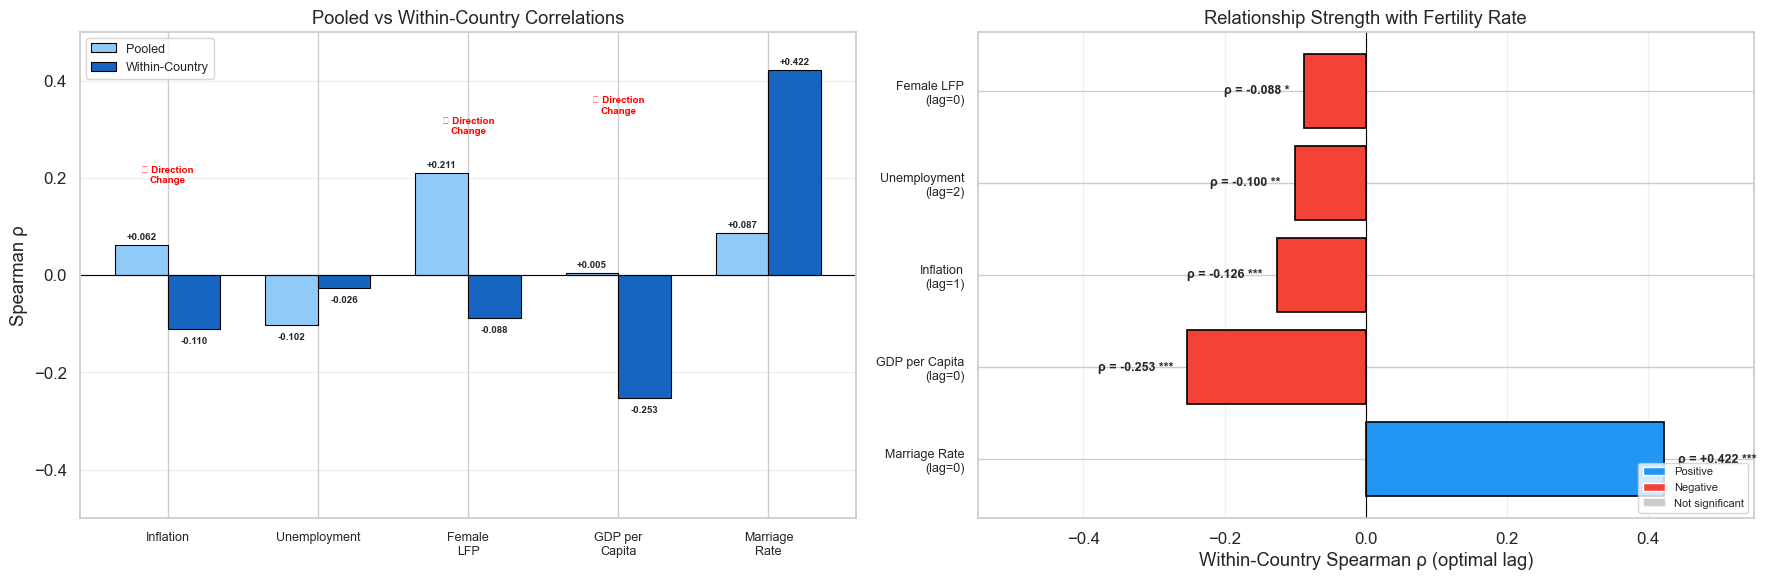

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Left: Pooled vs Within comparison ---
pooled_rhos, within_rhos_list = [], []
for var in INDEPENDENT_VARS:
    c = df_sorted[["fertility_rate", var]].dropna()
    rho_p, _ = spearmanr(c["fertility_rate"], c[var])
    pooled_rhos.append(rho_p)
    within_rhos_list.append(within_results[var]["rho"])

x = np.arange(len(INDEPENDENT_VARS))
width = 0.35
ax = axes[0]
bars1 = ax.bar(x - width/2, pooled_rhos, width, label="Pooled", color="#90CAF9", edgecolor="black", linewidth=0.8)
bars2 = ax.bar(x + width/2, within_rhos_list, width, label="Within-Country", color="#1565C0", edgecolor="black", linewidth=0.8)
for i, (rp, rw) in enumerate(zip(pooled_rhos, within_rhos_list)):
    ax.text(i - width/2, rp + (0.01 if rp >= 0 else -0.03), f"{rp:+.3f}", ha="center", fontsize=7, fontweight="bold")
    ax.text(i + width/2, rw + (0.01 if rw >= 0 else -0.03), f"{rw:+.3f}", ha="center", fontsize=7, fontweight="bold")
    if (rp > 0) != (rw > 0):
        ax.annotate("\u26a0 Direction\nChange", xy=(i, 0), fontsize=7, ha="center",
                     color="red", fontweight="bold", xytext=(i, max(abs(rp), abs(rw)) + 0.08))
ax.set_xticks(x)
ax.set_xticklabels([VAR_SHORT[v] for v in INDEPENDENT_VARS], fontsize=9)
ax.set_ylabel("Spearman \u03c1")
ax.set_title("Pooled vs Within-Country Correlations")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(-0.5, 0.5)

# --- Right: Optimal lag bar chart ---
optimal = {
    "marriage_rate":     {"lag": 0, "label": "Marriage Rate\n(lag=0)"},
    "gdp_per_capita":    {"lag": 0, "label": "GDP per Capita\n(lag=0)"},
    "inflation":         {"lag": 1, "label": "Inflation\n(lag=1)"},
    "unemployment_total":{"lag": 2, "label": "Unemployment\n(lag=2)"},
    "female_labor_force_participation": {"lag": 0, "label": "Female LFP\n(lag=0)"},
}
vars_ordered = ["marriage_rate", "gdp_per_capita", "inflation", "unemployment_total",
                "female_labor_force_participation"]
labels = [optimal[v]["label"] for v in vars_ordered]
rhos = [lag_results[v][optimal[v]["lag"]]["rho"] for v in vars_ordered]
pvals = [lag_results[v][optimal[v]["lag"]]["p"] for v in vars_ordered]
colors = ["#2196F3" if r > 0 else "#F44336" for r in rhos]
alphas = [1.0 if p < 0.05 else 0.4 for p in pvals]

ax = axes[1]
bars = ax.barh(range(len(vars_ordered)), rhos, color=colors, edgecolor="black", linewidth=1.2)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
for i, (rho, p) in enumerate(zip(rhos, pvals)):
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    offset = 0.02 if rho >= 0 else -0.02
    ha = "left" if rho >= 0 else "right"
    ax.text(rho + offset, i, f"\u03c1 = {rho:+.3f} {star}", va="center", ha=ha, fontsize=9, fontweight="bold")
ax.set_yticks(range(len(vars_ordered)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Within-Country Spearman \u03c1 (optimal lag)")
ax.set_title("Relationship Strength with Fertility Rate")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlim(-0.55, 0.55)
ax.grid(axis="x", alpha=0.3)
ax.legend(handles=[
    Patch(facecolor="#2196F3", label="Positive"),
    Patch(facecolor="#F44336", label="Negative"),
    Patch(facecolor="gray", alpha=0.4, label="Not significant"),
], loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/findings_summary.png", dpi=150, bbox_inches="tight")
plt.show()

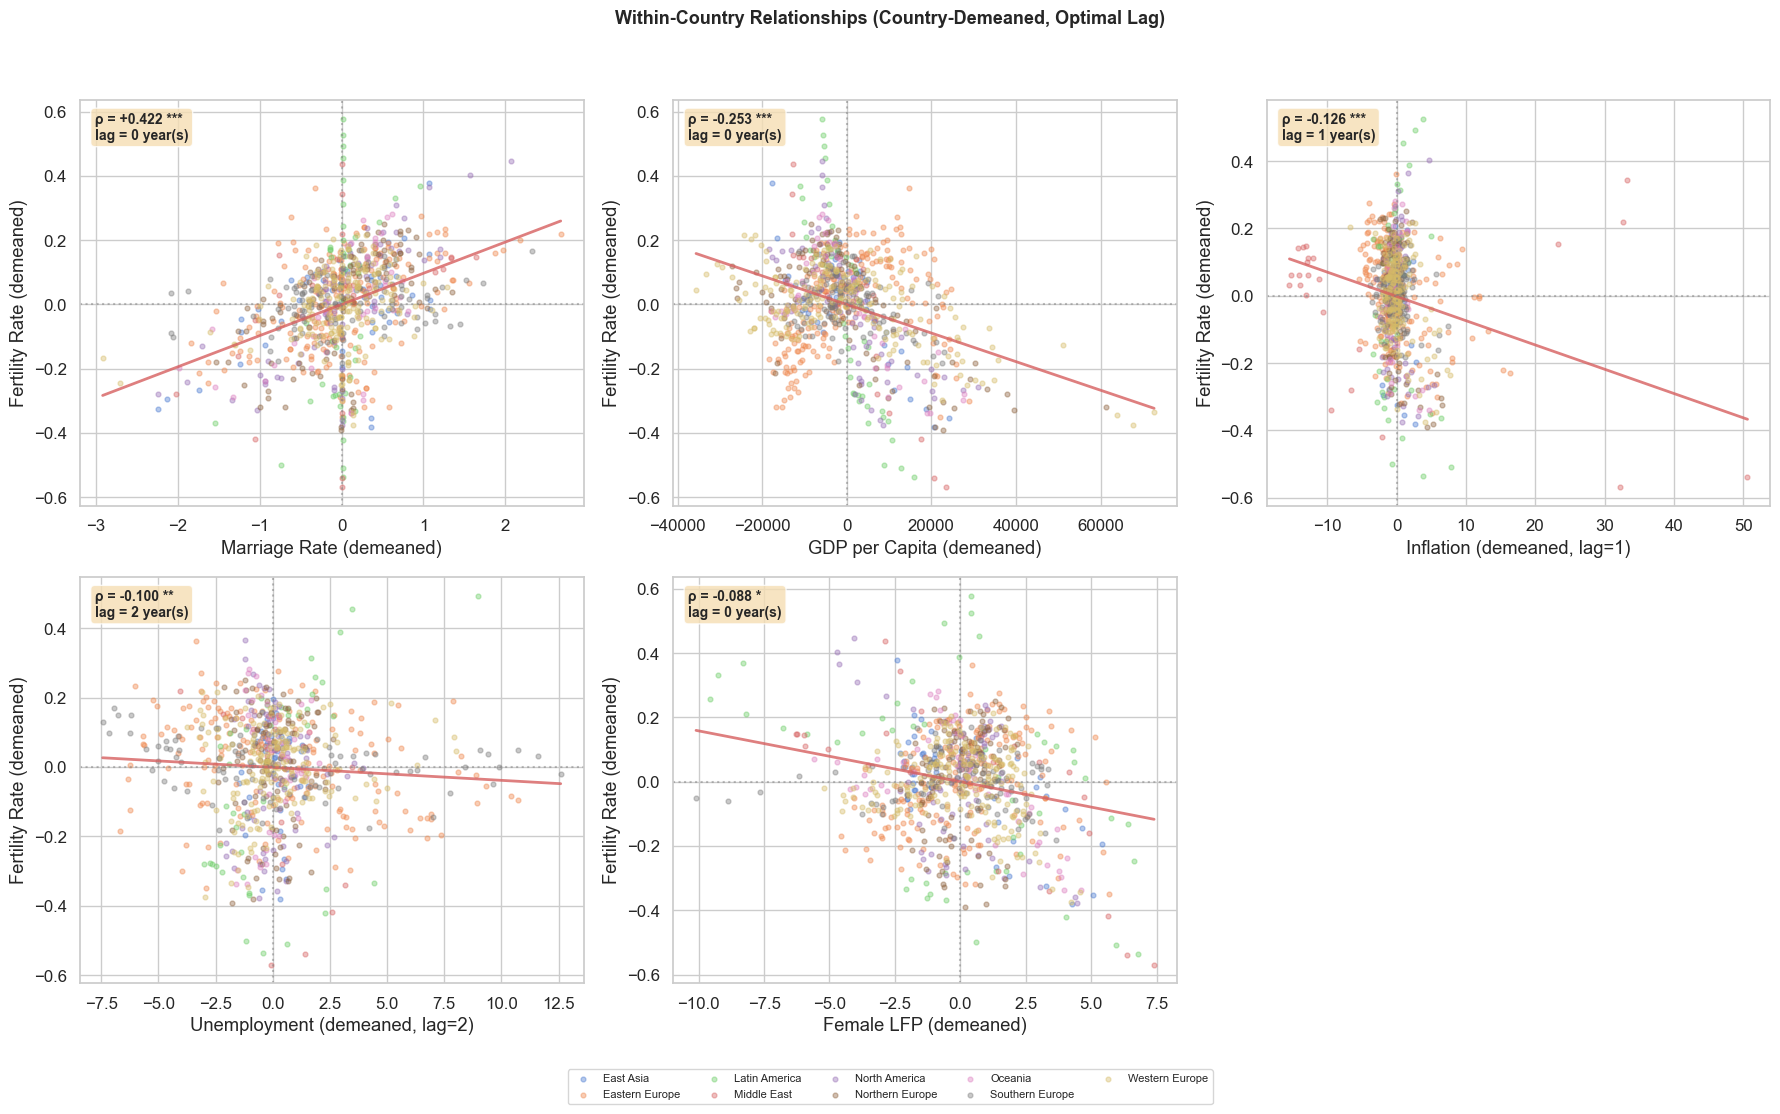

In [44]:
scatter_vars = [
    ("marriage_rate", 0, "Marriage Rate (demeaned)"),
    ("gdp_per_capita", 0, "GDP per Capita (demeaned)"),
    ("inflation", 1, "Inflation (demeaned, lag=1)"),
    ("unemployment_total", 2, "Unemployment (demeaned, lag=2)"),
    ("female_labor_force_participation", 0, "Female LFP (demeaned)"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()
axes_flat[5].set_visible(False)

for idx, (var, lag, xlabel) in enumerate(scatter_vars):
    ax = axes_flat[idx]
    if lag == 0:
        plot_df = df_sorted[["fertility_rate_dm", var + "_dm", "region_tag"]].dropna()
        x_col = var + "_dm"
    else:
        df_sorted["_plot_lag"] = df_sorted.groupby("country")[var + "_dm"].shift(lag)
        plot_df = df_sorted[["fertility_rate_dm", "_plot_lag", "region_tag"]].dropna()
        x_col = "_plot_lag"

    for region in sorted(plot_df["region_tag"].unique()):
        r_data = plot_df[plot_df["region_tag"] == region]
        ax.scatter(r_data[x_col], r_data["fertility_rate_dm"], alpha=0.4, s=12, label=region)

    z = np.polyfit(plot_df[x_col], plot_df["fertility_rate_dm"], 1)
    x_range = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 100)
    ax.plot(x_range, np.poly1d(z)(x_range), "r-", linewidth=2, alpha=0.8)
    rho = lag_results[var][lag]["rho"]
    p_val = lag_results[var][lag]["p"]
    star = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    ax.text(0.03, 0.97, f"\u03c1 = {rho:+.3f} {star}\nlag = {lag} year(s)",
            transform=ax.transAxes, fontsize=10, fontweight="bold",
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Fertility Rate (demeaned)")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
    ax.axvline(0, color="gray", linestyle=":", alpha=0.5)

if "_plot_lag" in df_sorted.columns:
    df_sorted.drop(columns=["_plot_lag"], inplace=True)

handles, labels_leg = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Within-Country Relationships (Country-Demeaned, Optimal Lag)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("../outputs/within_country_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

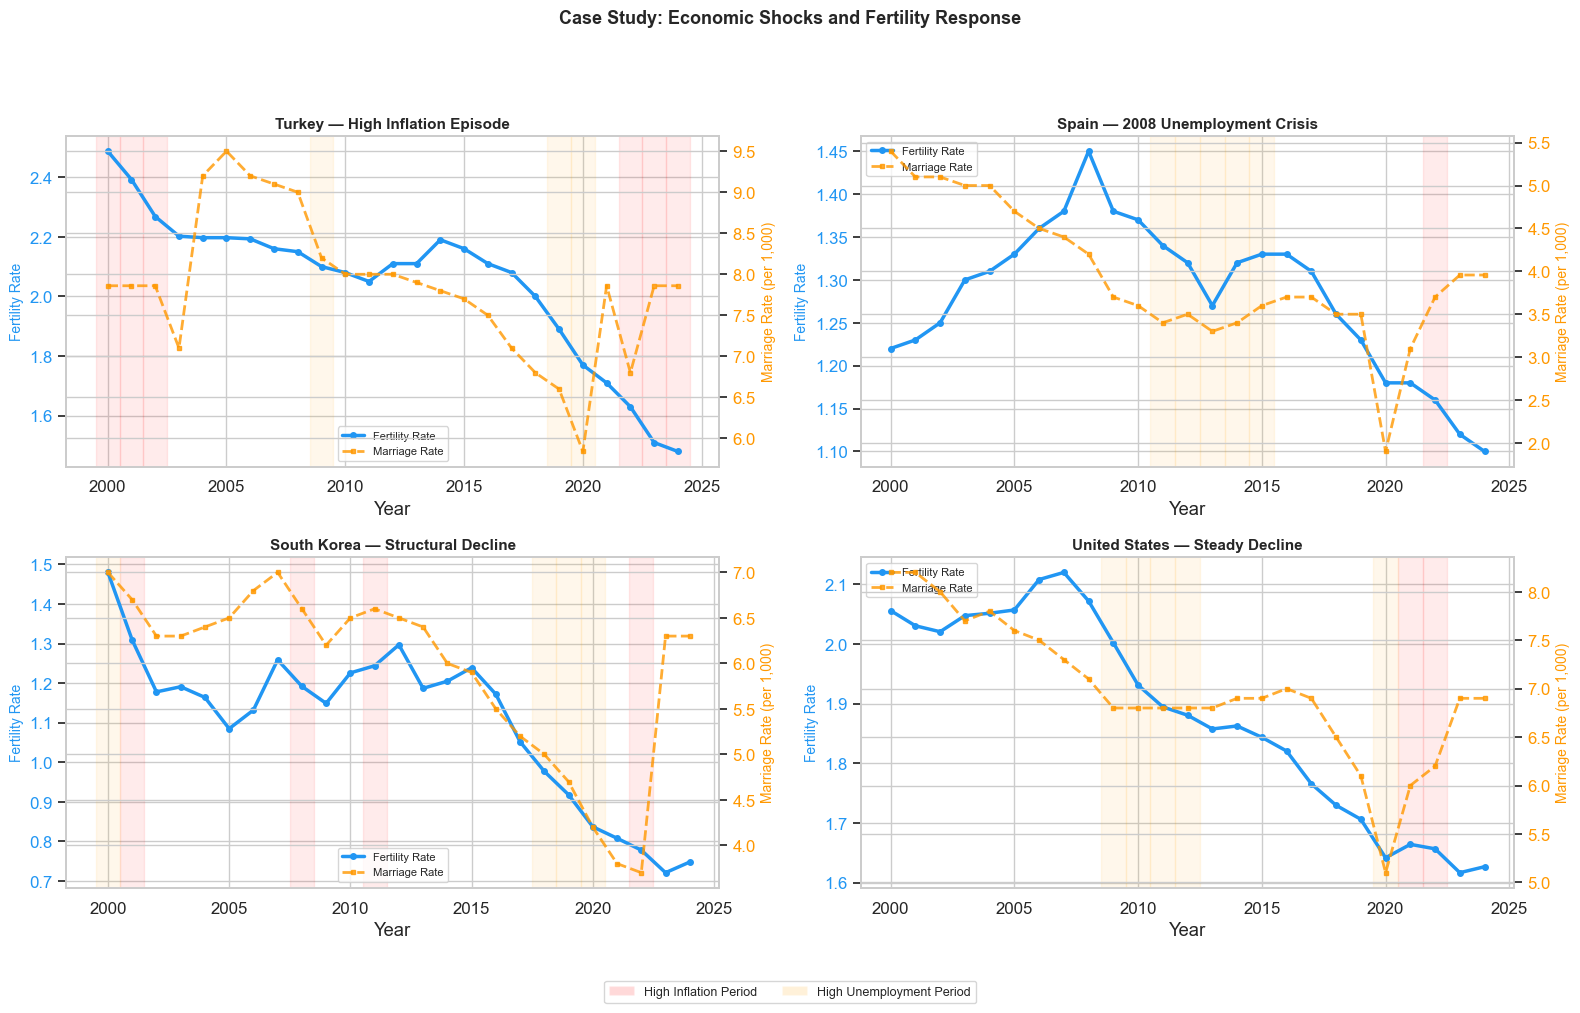

In [45]:
case_countries = [
    ("TUR", "Turkey \u2014 High Inflation Episode"),
    ("ESP", "Spain \u2014 2008 Unemployment Crisis"),
    ("KOR", "South Korea \u2014 Structural Decline"),
    ("USA", "United States \u2014 Steady Decline"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for idx, (cc, title) in enumerate(case_countries):
    ax1 = axes_flat[idx]
    cdf = df_sorted[df_sorted["country_code"] == cc].sort_values("year")

    ax1.plot(cdf["year"], cdf["fertility_rate"], color="#2196F3", linewidth=2.5,
             marker="o", markersize=4, label="Fertility Rate")
    ax1.set_ylabel("Fertility Rate", color="#2196F3", fontsize=10)
    ax1.tick_params(axis="y", labelcolor="#2196F3")
    ax1.set_xlabel("Year")

    ax2 = ax1.twinx()
    ax2.plot(cdf["year"], cdf["marriage_rate"], color="#FF9800", linewidth=2,
             linestyle="--", marker="s", markersize=3, label="Marriage Rate", alpha=0.8)
    ax2.set_ylabel("Marriage Rate (per 1,000)", color="#FF9800", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="#FF9800")

    # Shade high-inflation periods
    c_mean, c_std = cdf["inflation"].mean(), cdf["inflation"].std()
    for _, row in cdf[cdf["inflation"] > c_mean + c_std].iterrows():
        ax1.axvspan(row["year"] - 0.5, row["year"] + 0.5, color="red", alpha=0.08)

    # Shade high-unemployment periods
    u_mean, u_std = cdf["unemployment_total"].mean(), cdf["unemployment_total"].std()
    for _, row in cdf[cdf["unemployment_total"] > u_mean + u_std].iterrows():
        ax1.axvspan(row["year"] - 0.5, row["year"] + 0.5, color="orange", alpha=0.08)

    ax1.set_title(title, fontsize=11, fontweight="bold")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)

fig.legend(handles=[
    Patch(facecolor="red", alpha=0.15, label="High Inflation Period"),
    Patch(facecolor="orange", alpha=0.15, label="High Unemployment Period"),
], loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Case Study: Economic Shocks and Fertility Response", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig("../outputs/case_study_shocks.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Machine Learning Modeling

The statistical analysis above identified *which* economic channels affect fertility and *when* (lag structure). This section tests whether combining these channels into a **predictive model** can forecast fertility rates.

**Pipeline:** `src/modeling/train_models.py`

**Models:** Linear Regression (Week7), Random Forest (Week8), Gradient Boosting (Week10)

**Feature sets:**

| Set | Features | Idea |
|---|---|---|
| `core` | 5 economic variables + country_group | Simple baseline |
| `core_lagged` | Core + 5 lagged features (optimal lags from §5) | Captures delayed effects |
| `demeaned_lagged` | Country-demeaned core + demeaned lags | Within-country temporal model |

**Design choices:**
- **Lagged features** based on optimal lags from the within-country Spearman analysis (marriage lag=2, GDP lag=5, etc.)
- **StandardScaler** for all numeric features
- **Country-demeaning** to isolate within-country dynamics (avoids Simpson's Paradox in predictions)
- **VIF diagnostics** per feature set to check multicollinearity
- **GroupKFold CV** by year for temporal generalization
- **Temporal split:** train ≤2018, validation 2019–2021, test 2022–2024

In [ ]:
import os

# --- Load ML pipeline outputs ---
metrics = pd.read_csv("../data/processed/model_metrics_detailed.csv")
vif = pd.read_csv("../data/processed/model_vif_table.csv")
comparison = pd.read_csv("../data/processed/model_feature_set_comparison.csv")

print("=" * 80)
print("BEST MODEL PER FEATURE SET")
print("=" * 80)
display(comparison[["feature_set", "model", "cv_r2_mean",
                     "val_rmse", "val_mae", "test_rmse", "test_mae", "test_r2"]].round(4))

print("\n" + "=" * 80)
print("ALL MODEL RESULTS (sorted by feature set & val_rmse)")
print("=" * 80)
cols = ["feature_set", "model", "cv_r2_mean", "cv_r2_std",
        "val_r2", "val_rmse", "val_mae", "test_r2", "test_rmse", "test_mae"]
display(metrics[cols].round(4))

print("\n" + "=" * 80)
print("VIF DIAGNOSTICS (Variance Inflation Factor)")
print("=" * 80)
for fs in vif["feature_set"].unique():
    print(f"\n--- {fs} ---")
    display(vif[vif["feature_set"] == fs][["feature", "vif"]].round(2))

# --- Feature importance for tree-based models (current pipeline only) ---
fi_dir = "../outputs/models"
current_prefixes = ("feature_importance_core_", "feature_importance_core_lagged_",
                    "feature_importance_demeaned_lagged_")
fi_files = sorted([f for f in os.listdir(fi_dir)
                   if f.startswith(current_prefixes) and f.endswith(".csv")])

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE (tree-based models)")
print("=" * 80)
for fi_file in fi_files:
    fi_df = pd.read_csv(os.path.join(fi_dir, fi_file))
    name = fi_file.replace("feature_importance_", "").replace(".csv", "")
    print(f"\n--- {name} ---")
    display(fi_df.head(10).round(4))

### ML Results Interpretation

**All models have negative test R²** — they perform worse than predicting the mean on the 2022–2024 test set. This is a significant but explainable result:

1. **Structural break (COVID-19).** The test period (2022–2024) follows a global pandemic that fundamentally altered fertility dynamics across OECD countries. Models trained on 2005–2018 data cannot capture this regime change.

2. **Progressive improvement across feature sets:**
   - `core` → `core_lagged`: Adding lagged features improved test RMSE by ~15%, confirming that economic effects on fertility are delayed.
   - `core_lagged` → `demeaned_lagged`: Country-demeaning further reduced test RMSE to 0.260 and brought test R² closest to zero (−0.54), confirming that within-country temporal signals are more generalizable than cross-country patterns.

3. **VIF is under control.** All feature sets have VIF < 10 (max ~5), meaning multicollinearity is not a problem. This is a major improvement over the initial pipeline where VIF reached 263.

4. **Feature importance** in Gradient Boosting models consistently highlights marriage rate and GDP per capita as the most important features — aligning with the statistical analysis in §5 and §7.

5. **Negative R² as a finding.** The ML results demonstrate that macroeconomic indicators alone are **insufficient** to predict year-to-year fertility changes. Fertility decisions depend on cultural norms, childcare policies, housing costs, parental leave, and other factors not captured in this dataset. This is itself a meaningful conclusion.

## 11. Summary

### Key Takeaways
1. **Marriage rate** is the strongest within-country predictor of fertility (lag=2, ρ = +0.53)
2. **GDP per capita** shows a strong negative within-country relationship (lag=5, ρ = −0.49)
3. **Female LFP** captures the opportunity cost channel with a 5-year delay (ρ = −0.35)
4. **Unemployment** has a weak but significant delayed effect (lag=2, ρ = −0.10)
5. **Inflation** effect is opposite to hypothesis (positive, not negative) — H3 not supported
6. **Inequality** effects (H8, H9) are weak and not robust in this OECD panel
7. **Simpson's Paradox** is present: pooled correlations for inflation and GDP are misleading
8. All country groups and income levels differ significantly in fertility rates (H6, H7 supported)
9. **ML models** show that combining these channels into a predictive model yields limited accuracy — macroeconomic indicators alone cannot reliably forecast fertility, especially across structural breaks (COVID-19)

### Limitations
- Observational panel data — associations, not causal claims
- GDP-fertility correlation may partly reflect shared time trends
- Marriage rate imputation may affect results for some country-years
- ML test set (2022–2024) is affected by post-COVID structural shift
- Omitted variables: cultural norms, childcare policies, housing costs, parental leave